# Modelado: Random Forest & LightGBM

En este notebook se entrenan y evalúan dos modelos de clasificación para predecir si un individuo gana más o menos de 50K anuales.



Carga de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

# Tuning e Evaluación
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_validate
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

print(" Librerías cargadas correctamente")

 Librerías cargadas correctamente


##  Carga de datos

Se cargan los conjuntos de entrenamiento y test generados en el notebook de preprocesamiento. El target está ya codificado como variable binaria (0 = ≤50K, 1 = >50K).

In [2]:
df_train = pd.read_csv("../data/train.csv")
df_test  = pd.read_csv("../data/test.csv")

# Separamos features y target
X_train = df_train.drop(columns=['income'])
y_train = df_train['income']

X_test  = df_test.drop(columns=['income'])
y_test  = df_test['income']

print(f"Train → X: {X_train.shape} | y: {y_train.shape}")
print(f"Test  → X: {X_test.shape}  | y: {y_test.shape}")
print(f"\nDistribución del target en Train:")
print(y_train.value_counts(normalize=True).round(3))

Train → X: (39032, 23) | y: (39032,)
Test  → X: (9758, 23)  | y: (9758,)

Distribución del target en Train:
income
0    0.761
1    0.239
Name: proportion, dtype: float64


##  Configuración de la Validación Cruzada
Se define un `StratifiedKFold` de 5 folds. Al ser estratificado, cada fold mantiene la misma proporción de clases que el dataset original (~76% / ~24%), lo cual es importante dado el desbalance.

Se definen también dos funciones reutilizables:
- `evaluar_modelo`: ejecuta la validación cruzada, ajusta el modelo en todo el train y reporta las métricas en test.
- `plot_resultados`: genera la matriz de confusión y la curva ROC.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def evaluar_modelo(modelo, X_tr, y_tr, X_te, y_te, nombre="Modelo"):
    """Evalúa un modelo con CV en train y métricas finales en test."""
    
    # Cross-validation en train
    cv_results = cross_validate(
        modelo, X_tr, y_tr,
        cv=cv,
        scoring=['accuracy', 'f1', 'roc_auc'],
        return_train_score=False
    )
    
    print(f"{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(f"  [Cross-Validation en Train — 5 folds]")
    print(f"  Accuracy : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
    print(f"  F1-Score : {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
    print(f"  ROC-AUC  : {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
    
    # Ajuste final sobre todo el train
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]
    
    print(f"\n  [Evaluación en Test]")
    print(f"  Accuracy : {accuracy_score(y_te, y_pred):.4f}")
    print(f"  F1-Score : {f1_score(y_te, y_pred):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_te, y_prob):.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred, target_names=['<=50K', '>50K']))
    
    return modelo, y_pred, y_prob, cv_results


def plot_resultados(y_te, y_pred, y_prob, nombre):
    """Genera la matriz de confusión y la curva ROC."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    
    # Matriz de confusión
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred,
        display_labels=['<=50K', '>50K'],
        colorbar=False,
        ax=axes[0]
    )
    axes[0].set_title(f"Matriz de Confusión — {nombre}")
    
    # Curva ROC
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc = roc_auc_score(y_te, y_prob)
    axes[1].plot(fpr, tpr, label=f"AUC = {auc:.4f}", linewidth=2)
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"Curva ROC — {nombre}")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

print(" Funciones de evaluación definidas")

 Funciones de evaluación definidas



#  RANDOM FOREST

## 3. Random Forest — Baseline

Se entrena un Random Forest con los parámetros por defecto de scikit-learn (`n_estimators=100`). El objetivo es tener un punto de partida claro con el que comparar la versión tuneada.

Los resultados de la validación cruzada muestran el rendimiento medio esperado del modelo antes de ver el test.

In [4]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1
)

rf_base_fitted, rf_base_pred, rf_base_prob, rf_base_cv = evaluar_modelo(
    rf_baseline, X_train, y_train, X_test, y_test,
    nombre="Random Forest — Baseline"
)

  Random Forest — Baseline
  [Cross-Validation en Train — 5 folds]
  Accuracy : 0.8487 ± 0.0032
  F1-Score : 0.6608 ± 0.0075
  ROC-AUC  : 0.8949 ± 0.0015

  [Evaluación en Test]
  Accuracy : 0.8430
  F1-Score : 0.6509
  ROC-AUC  : 0.8920

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      7422
        >50K       0.70      0.61      0.65      2336

    accuracy                           0.84      9758
   macro avg       0.79      0.76      0.77      9758
weighted avg       0.84      0.84      0.84      9758



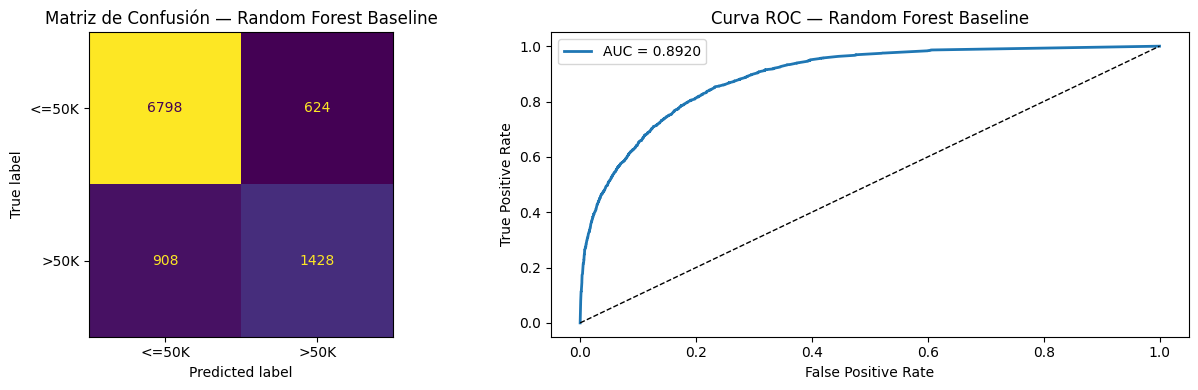

In [5]:
plot_resultados(y_test, rf_base_pred, rf_base_prob, "Random Forest Baseline")

##  Random Forest — Fine Tuning (RandomizedSearchCV)


Se realiza una búsqueda aleatoria (`RandomizedSearchCV`) sobre los hiperparámetros más relevantes del Random Forest. La métrica de optimización es el ROC-AUC, que es más informativa que la accuracy en datasets desbalanceados.

In [6]:
param_dist_rf = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf':  [1, 2, 4, 8],
    'max_features':      ['sqrt', 'log2', 0.5],
    'class_weight':      [None, 'balanced']
}

rf_tuned_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=30,               # Número de combinaciones a probar
    scoring='roc_auc',       # Métrica de optimización
    cv=cv,                   # StratifiedKFold(5) definido antes
    verbose=1,
    random_state=SEED,
    n_jobs=-1,
    refit=True               # Reajusta el mejor modelo sobre todo el train
)

rf_tuned_search.fit(X_train, y_train)

print("\n Búsqueda completada")
print(f"Mejores hiperparámetros encontrados:")
for k, v in rf_tuned_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor ROC-AUC en CV: {rf_tuned_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

 Búsqueda completada
Mejores hiperparámetros encontrados:
  n_estimators: 300
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: 0.5
  max_depth: 10
  class_weight: None

Mejor ROC-AUC en CV: 0.9200


In [7]:
# Evaluamos el mejor modelo encontrado en Test
rf_best = rf_tuned_search.best_estimator_

rf_tuned_pred = rf_best.predict(X_test)
rf_tuned_prob = rf_best.predict_proba(X_test)[:, 1]

print("="*55)
print("  Random Forest — Fine Tuning")
print("="*55)
print(f"  [Evaluación en Test]")
print(f"  Accuracy : {accuracy_score(y_test, rf_tuned_pred):.4f}")
print(f"  F1-Score : {f1_score(y_test, rf_tuned_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, rf_tuned_prob):.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_test, rf_tuned_pred, target_names=['<=50K', '>50K']))

  Random Forest — Fine Tuning
  [Evaluación en Test]
  Accuracy : 0.8637
  F1-Score : 0.6748
  ROC-AUC  : 0.9158

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      7422
        >50K       0.79      0.59      0.67      2336

    accuracy                           0.86      9758
   macro avg       0.83      0.77      0.79      9758
weighted avg       0.86      0.86      0.86      9758



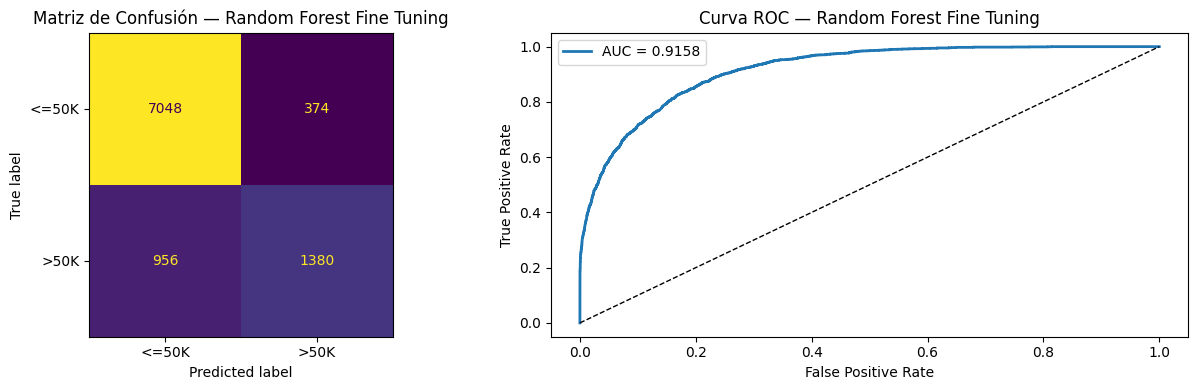

In [8]:
plot_resultados(y_test, rf_tuned_pred, rf_tuned_prob, "Random Forest Fine Tuning")

### Feature Importance — Random Forest Tuneado

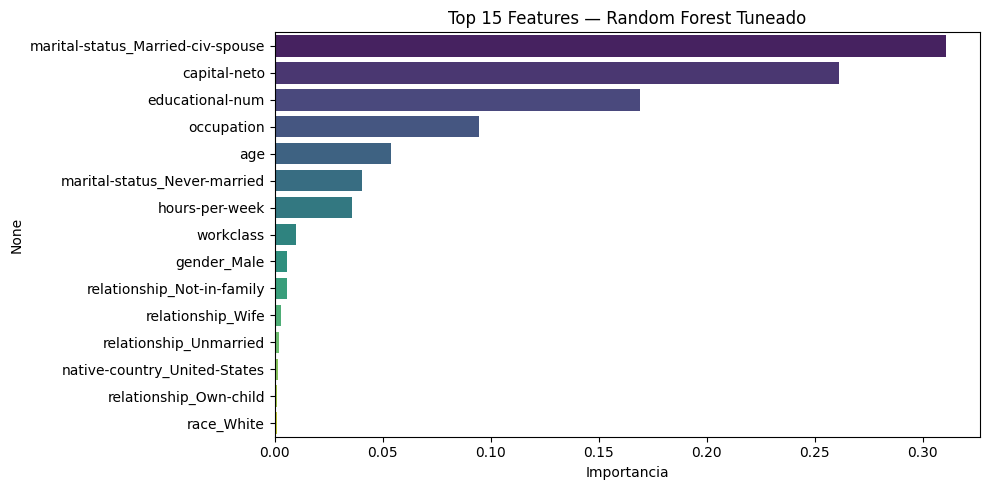

In [9]:
importances_rf = pd.Series(
    rf_best.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances_rf.values, y=importances_rf.index, palette='viridis')
plt.title("Top 15 Features — Random Forest Tuneado")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()


#  LIGHTGBM

##  LightGBM — Baseline

Se entrena LightGBM con su configuración por defecto. LightGBM es un algoritmo de gradient boosting basado en árboles, generalmente más rápido y preciso que Random Forest al capturar relaciones no lineales complejas.


In [10]:
lgbm_baseline = lgb.LGBMClassifier(
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

lgbm_base_fitted, lgbm_base_pred, lgbm_base_prob, lgbm_base_cv = evaluar_modelo(
    lgbm_baseline, X_train, y_train, X_test, y_test,
    nombre="LightGBM — Baseline"
)

  LightGBM — Baseline
  [Cross-Validation en Train — 5 folds]
  Accuracy : 0.8736 ± 0.0018
  F1-Score : 0.7110 ± 0.0059
  ROC-AUC  : 0.9294 ± 0.0013

  [Evaluación en Test]
  Accuracy : 0.8709
  F1-Score : 0.7057
  ROC-AUC  : 0.9258

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92      7422
        >50K       0.78      0.65      0.71      2336

    accuracy                           0.87      9758
   macro avg       0.84      0.79      0.81      9758
weighted avg       0.87      0.87      0.87      9758



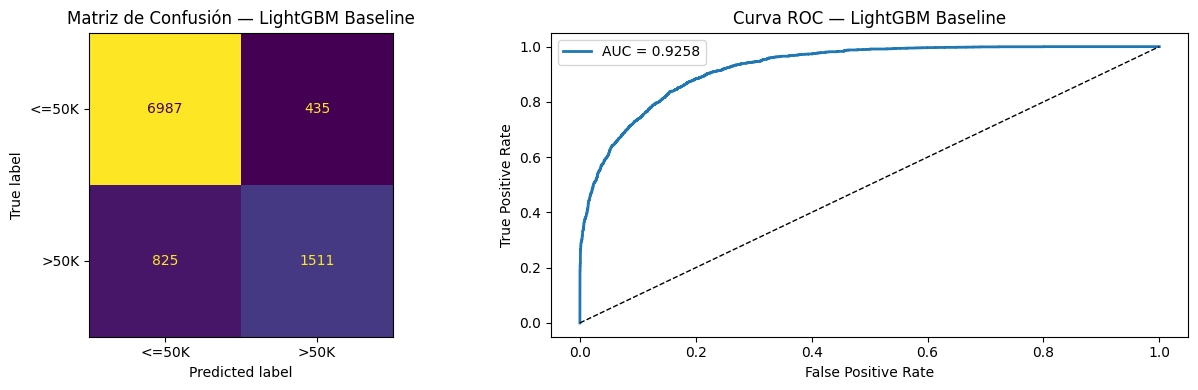

In [11]:
plot_resultados(y_test, lgbm_base_pred, lgbm_base_prob, "LightGBM Baseline")

##  LightGBM — Fine Tuning (RandomizedSearchCV)

Se realiza la misma búsqueda aleatoria que con Random Forest pero adaptada a los hiperparámetros propios de LightGBM. Se incluye `scale_pos_weight`, calculado como la ratio entre muestras negativas y positivas, para compensar el desbalance de clases.

In [12]:
# Calculamos scale_pos_weight para compensar el desbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = round(neg / pos, 2)
print(f"scale_pos_weight (neg/pos): {spw}")

param_dist_lgbm = {
    'n_estimators':       [100, 200, 300, 500, 700],
    'learning_rate':      [0.01, 0.05, 0.1, 0.2],
    'num_leaves':         [20, 31, 50, 70, 100],
    'max_depth':          [-1, 5, 10, 15, 20],
    'min_child_samples':  [10, 20, 30, 50],
    'subsample':          [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':   [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha':          [0.0, 0.1, 0.5, 1.0],
    'reg_lambda':         [0.0, 0.1, 0.5, 1.0],
    'scale_pos_weight':   [1, spw]
}

lgbm_tuned_search = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1),
    param_distributions=param_dist_lgbm,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=SEED,
    n_jobs=-1,
    refit=True
)

lgbm_tuned_search.fit(X_train, y_train)

print("\n Búsqueda completada")
print(f"Mejores hiperparámetros encontrados:")
for k, v in lgbm_tuned_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nMejor ROC-AUC en CV: {lgbm_tuned_search.best_score_:.4f}")

scale_pos_weight (neg/pos): 3.18
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 Búsqueda completada
Mejores hiperparámetros encontrados:
  subsample: 0.9
  scale_pos_weight: 3.18
  reg_lambda: 1.0
  reg_alpha: 0.0
  num_leaves: 50
  n_estimators: 300
  min_child_samples: 30
  max_depth: 10
  learning_rate: 0.05
  colsample_bytree: 0.6

Mejor ROC-AUC en CV: 0.9304


In [13]:
lgbm_best = lgbm_tuned_search.best_estimator_

lgbm_tuned_pred = lgbm_best.predict(X_test)
lgbm_tuned_prob = lgbm_best.predict_proba(X_test)[:, 1]

print("="*55)
print("  LightGBM — Fine Tuning")
print("="*55)
print(f"  [Evaluación en Test]")
print(f"  Accuracy : {accuracy_score(y_test, lgbm_tuned_pred):.4f}")
print(f"  F1-Score : {f1_score(y_test, lgbm_tuned_pred):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, lgbm_tuned_prob):.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_test, lgbm_tuned_pred, target_names=['<=50K', '>50K']))

  LightGBM — Fine Tuning
  [Evaluación en Test]
  Accuracy : 0.8259
  F1-Score : 0.7051
  ROC-AUC  : 0.9264

  Classification Report:
              precision    recall  f1-score   support

       <=50K       0.95      0.81      0.88      7422
        >50K       0.59      0.87      0.71      2336

    accuracy                           0.83      9758
   macro avg       0.77      0.84      0.79      9758
weighted avg       0.87      0.83      0.84      9758



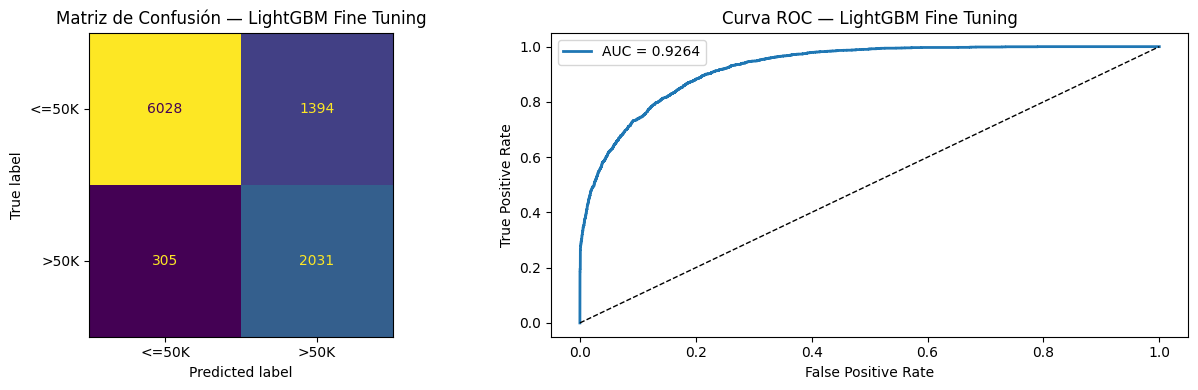

In [14]:
plot_resultados(y_test, lgbm_tuned_pred, lgbm_tuned_prob, "LightGBM Fine Tuning")

### Feature Importance — LightGBM Tuneado

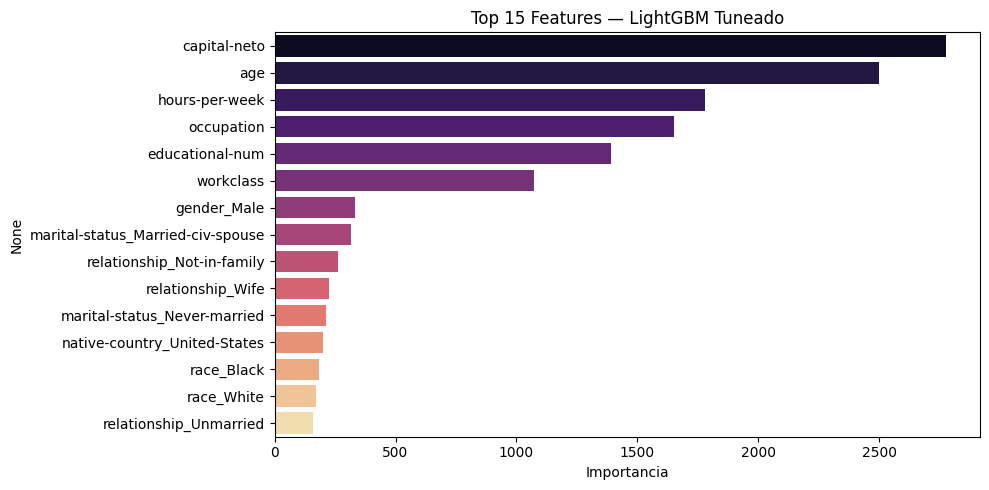

In [15]:
importances_lgbm = pd.Series(
    lgbm_best.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances_lgbm.values, y=importances_lgbm.index, palette='magma')
plt.title("Top 15 Features — LightGBM Tuneado")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()


##  Comparación Final de Modelos

Se comparan los cuatro modelos entrenados usando las métricas principales en el conjunto de test. El gráfico de barras permite ver de un vistazo qué modelo lidera en cada métrica, y las curvas ROC superpuestas muestran la capacidad discriminativa global de cada uno.

In [16]:
resultados = {
    'Modelo': [
        'RF Baseline',
        'RF Fine Tuning',
        'LightGBM Baseline',
        'LightGBM Fine Tuning'
    ],
    'Accuracy': [
        accuracy_score(y_test, rf_base_pred),
        accuracy_score(y_test, rf_tuned_pred),
        accuracy_score(y_test, lgbm_base_pred),
        accuracy_score(y_test, lgbm_tuned_pred)
    ],
    'F1-Score': [
        f1_score(y_test, rf_base_pred),
        f1_score(y_test, rf_tuned_pred),
        f1_score(y_test, lgbm_base_pred),
        f1_score(y_test, lgbm_tuned_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, rf_base_prob),
        roc_auc_score(y_test, rf_tuned_prob),
        roc_auc_score(y_test, lgbm_base_prob),
        roc_auc_score(y_test, lgbm_tuned_prob)
    ]
}

df_resultados = pd.DataFrame(resultados).set_index('Modelo').round(4)
print(df_resultados.to_string())

                      Accuracy  F1-Score  ROC-AUC
Modelo                                           
RF Baseline             0.8430    0.6509   0.8920
RF Fine Tuning          0.8637    0.6748   0.9158
LightGBM Baseline       0.8709    0.7057   0.9258
LightGBM Fine Tuning    0.8259    0.7051   0.9264


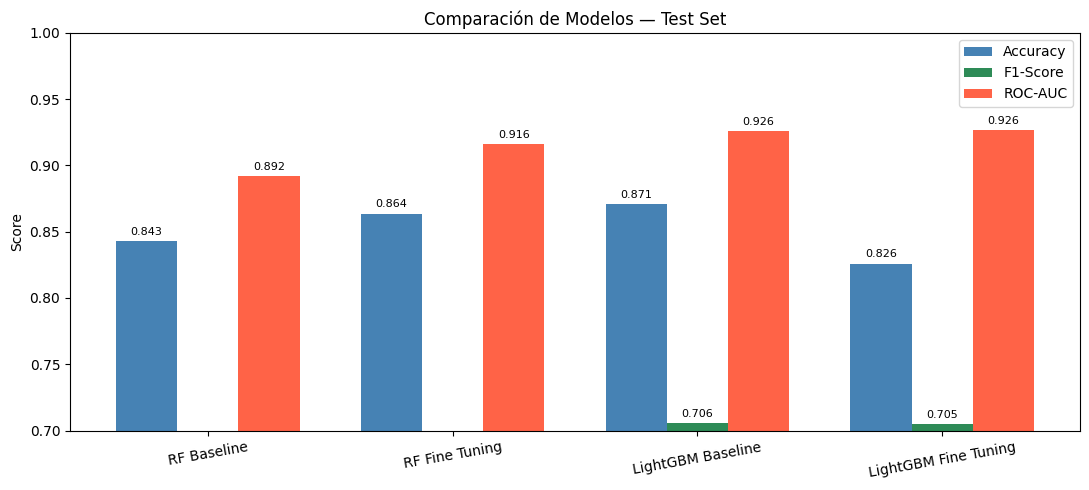

In [17]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(df_resultados))
width = 0.25

bars1 = ax.bar(x - width,   df_resultados['Accuracy'], width, label='Accuracy',  color='steelblue')
bars2 = ax.bar(x,           df_resultados['F1-Score'], width, label='F1-Score',  color='seagreen')
bars3 = ax.bar(x + width,   df_resultados['ROC-AUC'],  width, label='ROC-AUC',   color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(df_resultados.index, rotation=10)
ax.set_ylim(0.7, 1.0)
ax.set_ylabel("Score")
ax.set_title("Comparación de Modelos — Test Set")
ax.legend()

for bar in [*bars1, *bars2, *bars3]:
    ax.annotate(
        f"{bar.get_height():.3f}",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 3), textcoords="offset points",
        ha='center', va='bottom', fontsize=8
    )

plt.tight_layout()
plt.show()

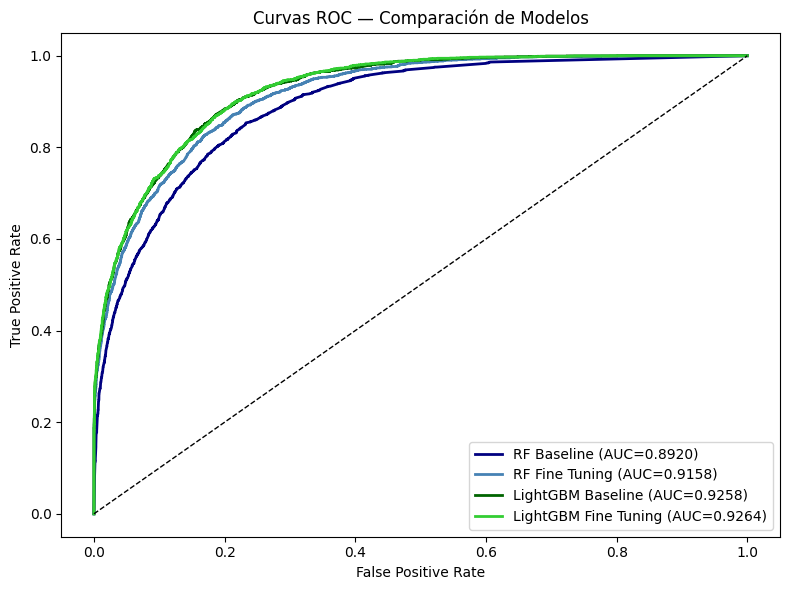


 Análisis completado. Revisa la tabla y los gráficos para seleccionar el mejor modelo.


In [18]:
# Curvas ROC de los 4 modelos superpuestas
fig, ax = plt.subplots(figsize=(8, 6))

modelos_roc = [
    (y_test, rf_base_prob,    'RF Baseline',          'navy'),
    (y_test, rf_tuned_prob,   'RF Fine Tuning',       'steelblue'),
    (y_test, lgbm_base_prob,  'LightGBM Baseline',    'darkgreen'),
    (y_test, lgbm_tuned_prob, 'LightGBM Fine Tuning', 'limegreen'),
]

for y_true, y_p, label, color in modelos_roc:
    fpr, tpr, _ = roc_curve(y_true, y_p)
    auc = roc_auc_score(y_true, y_p)
    ax.plot(fpr, tpr, label=f"{label} (AUC={auc:.4f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curvas ROC — Comparación de Modelos")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\n Análisis completado. Revisa la tabla y los gráficos para seleccionar el mejor modelo.")

In [19]:
modelos = {
    "RF Baseline":         rf_base_fitted,
    "RF Fine Tuning":      rf_best,
    "LightGBM Baseline":   lgbm_base_fitted,
    "LightGBM Fine Tuning": lgbm_best,
}

print(f"{'Modelo':<22} {'Train AUC':>10} {'Test AUC':>10} {'Gap':>8}")
print("-" * 54)
for nombre, modelo in modelos.items():
    train_auc = roc_auc_score(y_train, modelo.predict_proba(X_train)[:, 1])
    test_auc  = roc_auc_score(y_test,  modelo.predict_proba(X_test)[:, 1])
    gap = train_auc - test_auc
    flag = " " if gap > 0.05 else ""
    print(f"{nombre:<22} {train_auc:>10.4f} {test_auc:>10.4f} {gap:>+8.4f}{flag}")

Modelo                  Train AUC   Test AUC      Gap
------------------------------------------------------
RF Baseline                0.9968     0.8920  +0.1047 
RF Fine Tuning             0.9330     0.9158  +0.0172
LightGBM Baseline          0.9418     0.9258  +0.0160
LightGBM Fine Tuning       0.9474     0.9264  +0.0211


In [22]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

modelos = {
    "RF Baseline":          rf_base_fitted,
    "RF Fine Tuning":       rf_best,
    "LightGBM Baseline":    lgbm_base_fitted,
    "LightGBM Fine Tuning": lgbm_best,
}

resultados = []
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    resultados.append({
        "Modelo":     nombre,
        "Accuracy":   accuracy_score(y_test, y_pred),
        "Precision":  precision_score(y_test, y_pred),
        "Recall":     recall_score(y_test, y_pred),
        "F1-Score":   f1_score(y_test, y_pred),
        "ROC-AUC":    roc_auc_score(y_test, y_prob),
    })

df_comp = pd.DataFrame(resultados).set_index("Modelo").round(4)

df_comp.style.highlight_max(axis=0, props="font-weight: bold; color: green")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
RF Baseline,0.843000,0.695900,0.611300,0.650900,0.892000
RF Fine Tuning,0.863700,0.786800,0.590800,0.674800,0.915800
LightGBM Baseline,0.870900,0.776500,0.646800,0.705700,0.925800
LightGBM Fine Tuning,0.825900,0.593000,0.869400,0.705100,0.926400


LightGBM supera a Random Forest en prácticamente todas las métricas, tanto en baseline como tras el tuning. El baseline de LightGBM (AUC 0.9258) ya mejora al Random Forest tuneado (AUC 0.9158), lo que habla bien de la capacidad del algoritmo para este tipo de datos tabulares.
El RF Baseline es el modelo con más overfitting con diferencia: un gap de +0.10 entre train y test en AUC, frente a gaps de ~0.02 en el resto. El tuning lo corrige bastante, pero sin llegar al nivel de LightGBM.
En cuanto a qué modelo elegir como definitivo, depende de la prioridad:

Si lo que importa es detectar el máximo de personas con ingresos >50K (minimizar falsos negativos) → LightGBM Fine Tuning, que tiene el recall más alto (0.87).
Si se prefiere ser más preciso cuando se predice >50K (minimizar falsos positivos) → RF Fine Tuning, con la precision más alta (0.79) y mejor control del overfitting.